In [1]:
!pip install gdown

     |████████████████████████████████| 107 kB 10.2 MB/s eta 0:00:01
     |████████████████████████████████| 45 kB 5.9 MB/s  eta 0:00:01
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.10.0.2
    Uninstalling typing-extensions-3.10.0.2:
      Successfully uninstalled typing-extensions-3.10.0.2


In [4]:
import gdown

file_id = "11hRKwkFA46mD5W2OCoM-FvXTsn-73Zw6"  # no trailing slash
output_file = "individual_files_testing_segment.tfrecord"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=11hRKwkFA46mD5W2OCoM-FvXTsn-73Zw6
From (redirected): https://drive.google.com/uc?id=11hRKwkFA46mD5W2OCoM-FvXTsn-73Zw6&confirm=t&uuid=663a92d6-def3-4717-8226-723b1110e922
To: /workspace/individual_files_testing_segment.tfrecord
100%|██████████████████████████████████████████████████████████████████████████████████| 1.05G/1.05G [00:09<00:00, 113MB/s]


'individual_files_testing_segment.tfrecord'

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow==2.10.0
!{sys.executable} -m pip install waymo-open-dataset-tf-2-12-0

In [1]:
import tensorflow as tf
print("TF version:", tf.__version__)

from waymo_open_dataset import dataset_pb2 as open_dataset
from waymo_open_dataset.utils import frame_utils

print("Waymo Open Dataset working.")

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

2026-04-11 14:17:11.317227: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-11 14:17:11.484274: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-11 14:17:11.485053: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-11 14:17:12.522594: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF version: 2.12.0
Waymo Open Dataset working.


In [1]:
## Stable working version

import os
import tensorflow.compat.v1 as tf
import numpy as np
from PIL import Image

tf.enable_eager_execution()

from waymo_open_dataset.utils import frame_utils
from waymo_open_dataset import dataset_pb2 as open_dataset

# CONFIG
TFRECORD_PATH = "/home/jiale/Documents/eco_cars/data/individual_files_training_segment-10206293520369375008_2796_800_2816_800_with_camera_labels.tfrecord"
OUTPUT_IMAGE_DIR = "/home/jiale/Documents/eco_cars/data/images"
OUTPUT_DEPTH_DIR = "/home/jiale/Documents/eco_cars/data/depth"

def extract_frames_depth(TFRECORD_PATH, OUTPUT_IMAGE_DIR, OUTPUT_DEPTH_DIR) -> bool:
    try:
        os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)
        os.makedirs(OUTPUT_DEPTH_DIR, exist_ok=True)

        # LOAD DATASET
        dataset = tf.data.TFRecordDataset(TFRECORD_PATH, compression_type='')
        dataset = dataset.prefetch(1)

        # MAIN LOOP
        for frame_idx, data in enumerate(dataset):
            frame = open_dataset.Frame()
            frame.ParseFromString(bytearray(data.numpy()))

            # GET FRONT IMAGE
            front_image = None

            for img in frame.images:
                if img.name == open_dataset.CameraName.FRONT:
                    front_image = tf.image.decode_jpeg(img.image).numpy()
                    break

            if front_image is None:
                continue

            height, width = front_image.shape[:2]

            # GET FRONT CAMERA EXTRINSIC
            extrinsic = None
            for calib in frame.context.camera_calibrations:
                if calib.name == open_dataset.CameraName.FRONT:
                    extrinsic = np.array(calib.extrinsic.transform).reshape(4, 4)
                    break

            if extrinsic is None:
                continue

            vehicle_to_camera = np.linalg.inv(extrinsic)

            # PARSE RANGE IMAGES
            (range_images,
            camera_projections,
            _,
            range_image_top_pose) = frame_utils.parse_range_image_and_camera_projection(frame)

            # CONVERT TO POINT CLOUD
            points_ri1, cp_ri1 = frame_utils.convert_range_image_to_point_cloud(
                frame,
                range_images,
                camera_projections,
                range_image_top_pose,
                ri_index=0
            )

            points_ri2, cp_ri2 = frame_utils.convert_range_image_to_point_cloud(
                frame,
                range_images,
                camera_projections,
                range_image_top_pose,
                ri_index=1
            )

            # CREATE DEPTH MAP
            depth_map = np.full((height, width), np.inf, dtype=np.float32)

            # loop per lidar to preserve alignment
            num_lidars = len(points_ri1)

            for lidar_idx in range(num_lidars):

                # Combine returns for THIS lidar
                points = np.concatenate(
                    [points_ri1[lidar_idx], points_ri2[lidar_idx]],
                    axis=0
                )

                cp = np.concatenate(
                    [cp_ri1[lidar_idx], cp_ri2[lidar_idx]],
                    axis=0
                )

                if len(points) == 0:
                    continue

                # HANDLE MULTIPLE PROJECTIONS
                if cp.shape[1] == 6:
                    cp = cp.reshape(-1, 6)

                    cp1 = cp[:, :3]
                    cp2 = cp[:, 3:]

                    cp = np.vstack([cp1, cp2])
                    points = np.vstack([points, points])

                # TRANSFORM TO CAMERA FRAME
                depths = np.linalg.norm(points, axis=1)

                # FILTER FRONT CAMERA
                mask = cp[:, 0] == open_dataset.CameraName.FRONT

                u = cp[mask][:, 1].astype(np.int32)
                v = cp[mask][:, 2].astype(np.int32)
                z = depths[mask]

                # VALID PIXELS
                valid = (
                    (u >= 0) & (u < width) &
                    (v >= 0) & (v < height) &
                    (z > 0)
                )

                u = u[valid]
                v = v[valid]
                z = z[valid]

                # Z-BUFFER (KEEP CLOSEST)
                for ui, vi, zi in zip(u, v, z):
                    if zi < depth_map[vi, ui]:
                        depth_map[vi, ui] = zi

            depth_map[depth_map == np.inf] = np.nan

            # SAVE OUTPUTS
            img_path = os.path.join(OUTPUT_IMAGE_DIR, f"frame_{frame_idx:05d}.png")
            depth_path = os.path.join(OUTPUT_DEPTH_DIR, f"frame_{frame_idx:05d}.npy")

            Image.fromarray(front_image).save(img_path)
            np.save(depth_path, depth_map)

            # DELETING THE DEPTH MAP AND FRONT IMAGE FROM THE MEMORY
            del depth_map, front_image, u, v, z
            del points_ri1, points_ri2, cp_ri1, cp_ri2
            del points, cp, depths

            # print(f"Saved frame {frame_idx}")
        
        return True
    
    except:
        return False

2026-04-11 15:03:19.947932: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-11 15:03:19.980164: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-11 15:03:19.981086: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-11 15:03:20.869053: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Paths
depth_path = "/home/jiale/Documents/eco_cars/data/depth/frame_00100.npy"
image_path = "/home/jiale/Documents/eco_cars/data/images/frame_00100.png"

def view_image(depth_path, image_path) -> bool:
    # Load depth and RGB image
    try:
        depth = np.load(depth_path)
        rgb = np.array(Image.open(image_path))

        # Mask valid depth pixels
        valid_mask = ~np.isnan(depth) & (depth > 0)
        ys, xs = np.where(valid_mask)
        vals = depth[ys, xs]

        # Normalize for visualization (clip very large values)
        vmin = np.percentile(vals, 5)   # avoid extreme small outliers
        vmax = np.percentile(vals, 95)  # avoid extreme large outliers
        vals_norm = np.clip(vals, vmin, vmax)

        # Display RGB image
        plt.figure(figsize=(12,8))
        plt.imshow(rgb)

        # Overlay depth as scatter (only valid pixels)
        plt.scatter(xs, ys, c=vals_norm, cmap='jet', s=2, alpha=0.8)  # s=size of points
        plt.colorbar(label="Depth (meters)")
        plt.title("Sparse Depth Overlay on RGB (valid pixels only)")
        plt.axis("off")
        plt.show()
        plt.close()

        # Print statistics
        # print("Depth shape:", depth.shape)
        # print("Valid pixels:", np.sum(valid_mask))
        # print("Total pixels:", depth.size)
        # print("Density %:", 100 * np.sum(valid_mask) / depth.size)
        # print("Min depth (valid):", np.min(vals))
        # print("Max depth (valid):", np.max(vals))
        # print("Mean depth (valid):", np.mean(vals))

        return True
    except:
        return False

In [3]:
import numpy as np
from pathlib import Path
import sys

def combine_depth_npy(depth_dir: str, out_file: str):
    depth_dir = Path(depth_dir)
    out_file = Path(out_file)
    out_file.parent.mkdir(parents=True, exist_ok=True)  # <-- create directory if needed

    npy_files = sorted(depth_dir.glob("*.npy"))  # Sort by filename
    if not npy_files:
        raise FileNotFoundError(f"No .npy files found in {depth_dir.resolve()}")

    depth_stack = []
    stems = []

    for npy_path in npy_files:
        depth = np.load(npy_path).astype(np.float32)
        if depth.ndim == 3:
            depth = np.squeeze(depth)
        if depth.ndim != 2:
            raise ValueError(f"Unexpected depth shape {depth.shape} in {npy_path}")
        depth_stack.append(depth)
        stems.append(npy_path.stem)

    stack = np.stack(depth_stack, axis=0)  # (N,H,W)
    np.save(out_file, stack)
    np.save(out_file.with_name(out_file.stem + "_stems.npy"), np.array(stems, dtype=object))

    # print(f"Saved stacked depth array -> {out_file}  shape={stack.shape}")
    # print(f"Saved stems -> {out_file.with_name(out_file.stem + '_stems.npy')}")

    del(depth_stack)
    del(stack)

# Example usage
# combine_depth_npy(
#     "/home/jiale/Documents/eco_cars/data/depth",
#     "/home/jiale/Documents/eco_cars/data/depth/all_depths.npy"
# )


Processing: segment-2551868399007287341_3100_000_3120_000_with_camera_labels


2026-04-11 14:52:16.583140: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-11 14:52:16.584851: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-04-11 14:52:16.633788: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Pla

Displaying frame_00010 from segment-2551868399007287341_3100_000_3120_000_with_camera_labels


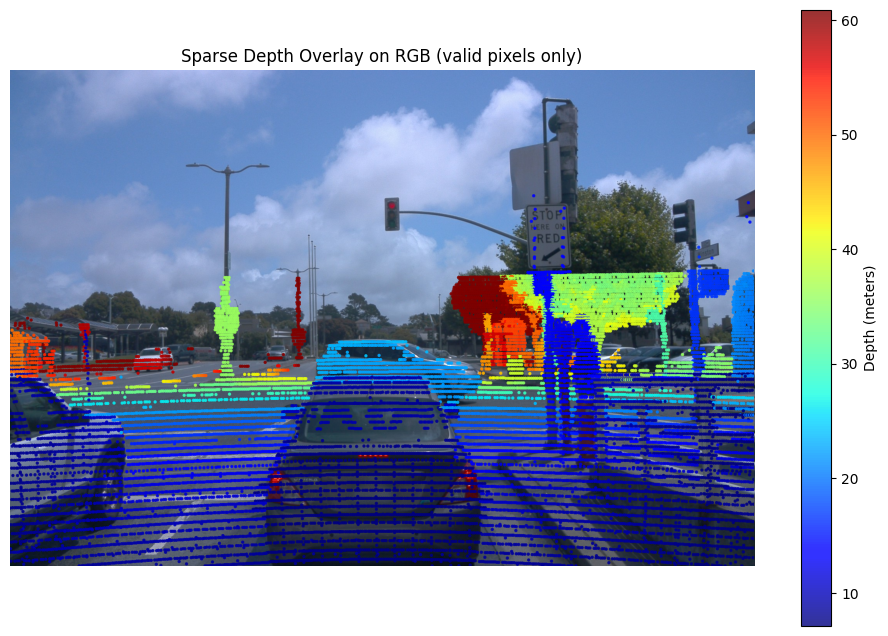

Error processing segment-2551868399007287341_3100_000_3120_000_with_camera_labels: [Errno 21] Is a directory: '/home/jiale/Documents/eco_cars/data/output_all_depth/segment-2551868399007287341_3100_000_3120_000_with_camera_labels'

Processing: segment-14127943473592757944_2068_000_2088_000_with_camera_labels


2026-04-11 14:59:37.652619: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


Displaying frame_00010 from segment-14127943473592757944_2068_000_2088_000_with_camera_labels


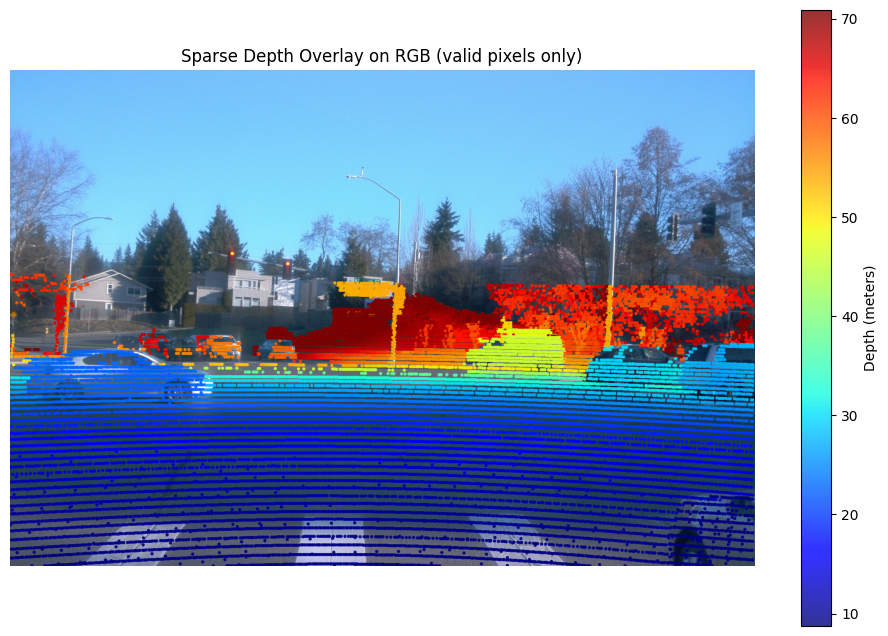

In [ ]:
import os
import random
import csv
import shutil

# CONFIG
MAIN_TFRECORD_DIR = "/home/jiale/Documents/eco_cars/data/t_records"
OUTPUT_ROOT_IMAGES = "/home/jiale/Documents/eco_cars/data/output_images"
OUTPUT_ROOT_DEPTHS = "/home/jiale/Documents/eco_cars/data/output_depth"
OUTPUT_ROOT_ALL_DEPTHS = "/home/jiale/Documents/eco_cars/data/output_all_depth"
LOG_CSV_PATH = os.path.join(OUTPUT_ROOT_IMAGES, "processing_log.csv")

os.makedirs(OUTPUT_ROOT_IMAGES, exist_ok=True)
os.makedirs(OUTPUT_ROOT_DEPTHS, exist_ok=True)
os.makedirs(OUTPUT_ROOT_ALL_DEPTHS, exist_ok=True)

# INIT CSV LOG
with open(LOG_CSV_PATH, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["tfrecord_name", "status", "message"])

def log_status(name, status, message=""):
    with open(LOG_CSV_PATH, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([name, status, message])

# GET TFRECORD FILES
tfrecord_files = [f for f in os.listdir(MAIN_TFRECORD_DIR) if f.endswith(".tfrecord")]

for tfrecord_file in tfrecord_files:
    tfrecord_path = os.path.join(MAIN_TFRECORD_DIR, tfrecord_file)
    record_name = os.path.splitext(tfrecord_file)[0]

    try:
        print(f"\nProcessing: {record_name}")

        # CREATE OUTPUT STRUCTURE
        record_dir_images = os.path.join(OUTPUT_ROOT_IMAGES, record_name)
        record_dir_depths = os.path.join(OUTPUT_ROOT_DEPTHS, record_name)
        all_depth_dir = os.path.join(OUTPUT_ROOT_ALL_DEPTHS, record_name)

        os.makedirs(record_dir_images, exist_ok=True)
        os.makedirs(record_dir_depths, exist_ok=True)

        # STEP 1: Extract frames + depths
        extract_frames_depth(
            TFRECORD_PATH=tfrecord_path,
            OUTPUT_IMAGE_DIR=record_dir_images,
            OUTPUT_DEPTH_DIR=record_dir_depths
        )

        #Combine depth maps
        combine_depth_npy(
            depth_dir=record_dir_depths,
            out_file=os.path.join(all_depth_dir, "all_depths.npy")
        )

        target_frame = "frame_00010"

        img_filename = f"{target_frame}.png"
        depth_filename = f"{target_frame}.npy"

        img_path = os.path.join(record_dir_images, img_filename)
        depth_path = os.path.join(record_dir_depths, depth_filename)

        if os.path.exists(img_path) and os.path.exists(depth_path):
            print(f"Displaying {target_frame} from {record_name}")

            view_image(
                image_path=img_path,
                depth_path=depth_path
            )

        # Compress all the folders using shutil to save space
        shutil.make_archive(record_dir_depths, "zip", record_dir_depths)
        shutil.make_archive(record_dir_images, "zip", record_dir_images)
        shutil.make_archive(all_depth_dir, "zip", all_depth_dir)

        os.remove(all_depth_dir)
        os.remove(record_dir_depths)
        os.remove(record_dir_images)

        log_status(record_name, "SUCCESS")

    except Exception as e:
        print(f"Error processing {record_name}: {e}")
        log_status(record_name, "FAILED", str(e))

print("\nProcessing complete.")
print("Log saved at:", LOG_CSV_PATH)

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import random
import csv
import shutil
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

# CONFIG
MAIN_TFRECORD_DIR = "/home/jiale/Documents/eco_cars/data/t_records"
OUTPUT_ROOT_IMAGES = "/home/jiale/Documents/eco_cars/data/output_images"
OUTPUT_ROOT_DEPTHS = "/home/jiale/Documents/eco_cars/data/output_depth"
OUTPUT_ROOT_ALL_DEPTHS = "/home/jiale/Documents/eco_cars/data/output_all_depth"
LOG_CSV_PATH = os.path.join(OUTPUT_ROOT_IMAGES, "processing_log.csv")

# NO OF MULTITHREADED WORKERS
max_workers = 1

# LOCKS FOR PREVENTING RACE CONDITIONS AND DEADLOCKS
csv_lock = threading.Lock()
print_lock = threading.Lock()
display_lock = threading.Lock()

os.makedirs(OUTPUT_ROOT_IMAGES, exist_ok=True)
os.makedirs(OUTPUT_ROOT_DEPTHS, exist_ok=True)
os.makedirs(OUTPUT_ROOT_ALL_DEPTHS, exist_ok=True)

# INIT CSV LOG
with open(LOG_CSV_PATH, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["tfrecord_name", "status", "message"])

# IMPLEMENTING A LOCK FOR ACCESSING CSV FILES
def log_status(name, status, message=""):
    with csv_lock:    
        with open(LOG_CSV_PATH, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([name, status, message])

# IMPLEMENTING A LOCK FOR PRINTING SAFELY ON THE TERMINAL
def safe_print(*args, **kwargs):
    with print_lock:
        print(*args, **kwargs)

# FUNCTION TO PROCESS INDIVIDUAL TRECORDS BY EVERY WORKER
def process_individual_trecords(tfrecord_file):
    tfrecord_path = os.path.join(MAIN_TFRECORD_DIR, tfrecord_file)
    record_name = os.path.splitext(tfrecord_file)[0]

    try:
        safe_print(f"\nProcessing: {record_name}")

        # CREATE OUTPUT STRUCTURE
        record_dir_images = os.path.join(OUTPUT_ROOT_IMAGES, record_name)
        record_dir_depths = os.path.join(OUTPUT_ROOT_DEPTHS, record_name)
        all_depth_dir = os.path.join(OUTPUT_ROOT_ALL_DEPTHS, record_name)

        os.makedirs(record_dir_images, exist_ok=True)
        os.makedirs(record_dir_depths, exist_ok=True)

        # EXTRACT FRAMES + DEPTHS
        extract_frames_depth(
            TFRECORD_PATH=tfrecord_path,
            OUTPUT_IMAGE_DIR=record_dir_images,
            OUTPUT_DEPTH_DIR=record_dir_depths
        )

        # COMBINE DEPTH MAPS
        combine_depth_npy(
            depth_dir=record_dir_depths,
            out_file=os.path.join(all_depth_dir, "all_depths.npy")
        )

        target_frame = "frame_00010"

        img_filename = f"{target_frame}.png"
        depth_filename = f"{target_frame}.npy"

        img_path = os.path.join(record_dir_images, img_filename)
        depth_path = os.path.join(record_dir_depths, depth_filename)

        if os.path.exists(img_path) and os.path.exists(depth_path):
            safe_print(f"Displaying {target_frame} from {record_name}")

            with display_lock:
                view_image(
                    image_path=img_path,
                    depth_path=depth_path
                )

        # COMPRESS ALL THE FOLDERS USING SHUTIL TO SAVE SPACE
        shutil.make_archive(record_dir_depths, "zip", record_dir_depths)
        shutil.make_archive(record_dir_images, "zip", record_dir_images)
        shutil.make_archive(all_depth_dir, "zip", all_depth_dir)

        # REMOVING FILES TO SAVE SPACE
        shutil.rmtree(all_depth_dir)
        shutil.rmtree(record_dir_depths)
        shutil.rmtree(record_dir_images)

        log_status(record_name, "SUCCESS")
        safe_print(f"Done: {record_name}")

    except Exception as e:
        safe_print(f"Error processing {record_name}: {e}")
        log_status(record_name, "FAILED", str(e))

def main():
    # GET TFRECORD FILES
    tfrecord_files = [f for f in os.listdir(MAIN_TFRECORD_DIR) if f.endswith(".tfrecord")]

    # CREATING MULTIPLE WORKERS(THREADS) FOR EXECUTION
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {}

        for files in tfrecord_files:
            future = executor.submit(process_individual_trecords, files)
            futures[future] = files

        for future in as_completed(futures):
            filename = futures[future]

            try:
                future.result()
            except Exception as e:
                safe_print(f"Unhandled error for {filename}: {e}")

    print("\nProcessing complete.")
    print("Log saved at:", LOG_CSV_PATH)

if __name__ == "__main__":
    main()


Processing: segment-2551868399007287341_3100_000_3120_000_with_camera_labels

Processing: segment-14127943473592757944_2068_000_2088_000_with_camera_labels


2026-04-11 15:03:41.432401: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-11 15:03:41.434257: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-04-11 15:03:41.470735: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Pla

In [7]:
## Program to zip all the files in a folder
import os
import shutil


#directory = '/home/jiale/Documents/eco_cars/data/output_images'
# directory = '/home/jiale/Documents/eco_cars/data/output_depth'
directory = '/home/jiale/Documents/eco_cars/data/output_all_depth'

for root, dirs, files in os.walk(directory):
    for folder in dirs:
        folder_path = os.path.join(root, folder)
        archive_path = os.path.join(root, folder)  # where zip will be saved
        
        shutil.make_archive(archive_path, "zip", folder_path)

In [ ]:
import numpy as np
import pandas as pd

#    Load the data   
# If your file is a numpy file
data = np.load("/Users/devrathod/Documents/classes_2026/Senior Design/Eco-Cars-Depth-Estimation-2026/data/output/all_depths.npy", allow_pickle=True)

#    Check type   
print("Type:", type(data))

#    Check shape / length   
try:
    print("Shape:", data.shape)
except:
    print("Length:", len(data))

#    Convert to list if numpy object array   
data_list = list(data)

print("Total frames:", len(data_list))

import cv2

img = cv2.imread("/Users/devrathod/Documents/classes_2026/Senior Design/Eco-Cars-Depth-Estimation-2026/data/output/images/frame_00001.png")

print(img.shape)